<div style="display:flex; align-items:center; gap:18px; text-align:left">
<img src="https://sebastiancontz.github.io/ust-introduccion-machine-learning/assets/logo-ust.svg" width="100">
<div>
<p>Ingeniería en Información y Control de Gestión</p>
<p>Facultad de Economía y Negocios</p>
<p>Introducción a Machine Learning</p>
<p>Semana 02: Formulación de problemas predictivos</p>
</div>
</div>

# 02 · Formulación de problemas predictivos

Hoy no se entrena ningún modelo. Ni una línea.

Este notebook hace tres cosas, y las tres ocurren **antes** de que exista un modelo:

1. Contar, para descubrir qué representa realmente una fila del archivo.
2. **Construir** la fila que la decisión necesita, que no es la que vino.
3. Calcular el **baseline** sobre las dos versiones y comparar.

Al final van a ver el número con que abrió la clase: dos equipos, el mismo archivo, y una diferencia
de más del triple producida por una sola decisión.

## Preparación del entorno

En Colab estas librerías ya vienen instaladas, así que la celda siguiente termina en segundos. Está
igual porque el notebook también tiene que correr fuera de Colab, y porque dejar escrito de qué
depende un análisis es parte de que sea reproducible.

In [1]:
%%capture
!pip install -q pandas numpy matplotlib seaborn scikit-learn

## Cargar datos

En **Colab** los datos se leen del repo público del curso; en local, desde `../datasets/`. La misma
celda funciona en los dos casos.

El archivo es un registro de ausencias de una empresa de servicios: tres años de historia.

In [2]:
import os
import pandas as pd

REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-introduccion-machine-learning-colab/main/introduccion-machine-learning/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

# periodo se lee como texto: es un año-mes, no un número con el que se opere
df = pd.read_csv(BASE + 'absentismo_laboral.csv', dtype={'periodo': str})
df['periodo'] = df['periodo'].fillna('')

print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (740, 22)


,id_empleado,periodo,mes,dia_semana,estacion,motivo_ausencia,horas_ausencia,edad,antiguedad_anios,nivel_educacion,...,distancia_casa_trabajo_km,gasto_transporte,carga_trabajo_promedio_dia,cumplimiento_meta_pct,falta_disciplinaria,bebedor_social,fumador_social,peso_kg,altura_cm,indice_masa_corporal
0,E-11,2007-07,7,martes,verano,ausencia injustificada,4,33,13,media,...,36,289,239.554,97,no,si,no,90,172,30
1,E-36,2007-07,7,martes,verano,sin motivo registrado,0,50,18,media,...,13,118,239.554,97,si,si,no,98,178,31
2,E-03,2007-07,7,miercoles,verano,consulta medica,2,38,18,media,...,51,179,239.554,97,no,si,no,89,170,31
3,E-07,2007-07,7,jueves,verano,enfermedades de los ojos,4,39,14,media,...,5,279,239.554,97,no,si,si,68,168,24
4,E-11,2007-07,7,jueves,verano,consulta medica,2,33,13,media,...,36,289,239.554,97,no,si,no,90,172,30


---

# Parte 1 · ¿Qué representa una fila?

740 filas. La pregunta que decide todo lo demás es de qué son esas 740 filas.

> **Antes de ejecutar la celda siguiente, respondan:** ¿cuántos empleados distintos creen que hay?

In [3]:
print('Filas en el archivo :', len(df))
print('Empleados distintos :', df['id_empleado'].nunique())

Filas en el archivo : 740
Empleados distintos : 36


Treinta y seis personas en 740 filas. Entonces **una fila no es un empleado**: es un *episodio de
ausencia*, y una misma persona aparece muchas veces.

Veamos hasta qué punto.

In [4]:
por_empleado = df['id_empleado'].value_counts()

print('Registros por empleado')
print('  mínimo :', por_empleado.min())
print('  mediana:', int(por_empleado.median()))
print('  máximo :', por_empleado.max())

Registros por empleado
  mínimo : 1
  mediana: 9
  máximo : 113


### El caso testigo

Un empleado concreto, en un mes concreto. Miren la columna `motivo_ausencia`: cuenta una historia.

In [5]:
caso = df[(df['id_empleado'] == 'E-03') & (df['periodo'] == '2010-02')]

print(f'{len(caso)} episodios, {caso["horas_ausencia"].sum()} horas en total')
caso[['id_empleado', 'periodo', 'dia_semana', 'motivo_ausencia', 'horas_ausencia']]

15 episodios, 45 horas en total


,id_empleado,periodo,dia_semana,motivo_ausencia,horas_ausencia
585,E-03,2010-02,martes,enfermedades del sistema musculoesqueletico,8
588,E-03,2010-02,miercoles,kinesiologia,2
590,E-03,2010-02,jueves,kinesiologia,2
593,E-03,2010-02,viernes,kinesiologia,2
595,E-03,2010-02,lunes,kinesiologia,2
597,E-03,2010-02,miercoles,kinesiologia,3
598,E-03,2010-02,jueves,kinesiologia,3
602,E-03,2010-02,viernes,kinesiologia,3
605,E-03,2010-02,miercoles,kinesiologia,2
606,E-03,2010-02,jueves,enfermedades del sistema musculoesqueletico,8


Una dolencia musculoesquelética y una tanda de sesiones de kinesiología. Quince filas que, para la
decisión que queremos apoyar, son **un solo hecho**: este empleado faltó 45 horas ese mes.

### Y una fila tampoco es siempre una ausencia

Hay filas en la tabla que no son episodios de ausencia. Se detectan cruzando dos columnas.

In [6]:
disciplinarias = df[df['falta_disciplinaria'] == 'si']

print('Filas con falta disciplinaria:', len(disciplinarias))
print('Horas de ausencia que registran:', sorted(disciplinarias['horas_ausencia'].unique()))
print('Motivos que registran:', disciplinarias['motivo_ausencia'].unique())

Filas con falta disciplinaria: 40
Horas de ausencia que registran: [np.int64(0)]
Motivos que registran: <StringArray>
['sin motivo registrado']
Length: 1, dtype: str


Cuarenta filas, todas con **cero horas** y **sin motivo**. Son registros disciplinarios que quedaron
guardados en una tabla de ausencias. No son el evento que el nombre del archivo promete, y hay que
sacarlas antes de calcular nada.

Esto no se detecta leyendo los nombres de las columnas. Se detecta contando y cruzando.

---

# Parte 2 · Construir la fila que la decisión necesita

La decisión es **cuántos turnos de reemplazo cubrir el mes que viene**. Se toma por empleado y una
vez al mes, así que la fila tiene que ser el **empleado-mes**.

El archivo no la trae. Hay que construirla, y son dos pasos.

<p align="center"></p>

### Paso 1 · Agrupar los episodios

Un `groupby` por empleado y período. Antes de ejecutar, una advertencia: **este paso todavía tiene
un problema**, y es el punto de la clase. Mírenlo y sigan.

In [7]:
fechado = df[df['periodo'] != '']          # las 3 filas sin mes registrado quedan fuera
fechado = fechado[fechado['falta_disciplinaria'] == 'no']   # y los registros disciplinarios también

observados = (fechado
              .groupby(['id_empleado', 'periodo'])['horas_ausencia']
              .sum()
              .reset_index())

print('Filas empleado-mes que aparecen en el archivo:', len(observados))
observados.head()

Filas empleado-mes que aparecen en el archivo: 366


,id_empleado,periodo,horas_ausencia
0,E-01,2007-07,8
1,E-01,2007-08,4
2,E-01,2007-12,8
3,E-01,2008-04,3
4,E-01,2008-06,16


### Paso 2 · Los meses en que no pasó nada

366 filas. Pero hay 33 empleados con historial y 37 meses de ventana, o sea **1.221** combinaciones
posibles de empleado y mes.

Faltan 855. ¿Dónde están?

No están porque **no hubo ausencia** esos meses, y un sistema registra cuando *pasa* algo. Pero un
mes sin ausencias no es un dato faltante: es una observación perfectamente válida, y vale **cero
horas**.

Si no se construyen, el promedio se calcula solo sobre los meses malos.

In [8]:
empleados = sorted(fechado['id_empleado'].unique())
periodos = sorted(fechado['periodo'].unique())

print(f'{len(empleados)} empleados x {len(periodos)} meses = {len(empleados) * len(periodos)} filas posibles')
print(f'Ventana: de {periodos[0]} a {periodos[-1]}')

grilla = pd.MultiIndex.from_product([empleados, periodos], names=['id_empleado', 'periodo'])

completa = (observados
            .set_index(['id_empleado', 'periodo'])['horas_ausencia']
            .reindex(grilla, fill_value=0)      # el mes sin ausencias vale 0, no NaN
            .reset_index())

ceros = (completa['horas_ausencia'] == 0).sum()
print(f'\nFilas en la tabla completa: {len(completa)}')
print(f'De ellas, en cero: {ceros}  ({ceros / len(completa):.0%})')
completa.head()

33 empleados x 37 meses = 1221 filas posibles
Ventana: de 2007-07 a 2010-07

Filas en la tabla completa: 1221
De ellas, en cero: 855  (70%)


,id_empleado,periodo,horas_ausencia
0,E-01,2007-07,8
1,E-01,2007-08,4
2,E-01,2007-09,0
3,E-01,2007-10,0
4,E-01,2007-11,0


El **70 %** de la tabla son ceros que no estaban en el archivo. Esa es la tabla que la decisión
necesita, y hubo que construirla.

> **Chequeo rápido:** si un empleado entró a la empresa a mitad de la ventana, ¿corresponde ponerle
> cero en los meses anteriores? Piénsenlo. La respuesta es que **no**, y por eso este paso es una
> decisión de formulación y no un `reindex` automático. En este archivo no tenemos fecha de ingreso,
> así que asumimos que los 33 estuvieron los 37 meses; en un caso real, eso hay que verificarlo.

---

# Parte 3 · El baseline

El baseline es la predicción más simple posible **sin modelo**. Para una cantidad, predecir siempre
el promedio.

En la clase pasada ya lo vieron funcionar: `DummyClassifier` sobre la cartera de morosidad daba 77 %
de exactitud y detectaba cero morosos. Es el mismo objeto, en su versión para cantidades.

> **Antes de ejecutar:** ¿cuál creen que va a ser el promedio de horas por empleado-mes?

In [9]:
from sklearn.dummy import DummyRegressor

y = completa['horas_ausencia']
X = completa[['id_empleado']]        # el baseline ni las mira: predice lo mismo para todos

piso = DummyRegressor(strategy='mean').fit(X, y)
prediccion = piso.predict(X)

print(f'El baseline predice {prediccion[0]:.2f} horas para todos los empleados, todos los meses.')

El baseline predice 4.20 horas para todos los empleados, todos los meses.


Cuatro horas. Y ahora la pregunta que importa: **¿cuánto se equivoca?**

Lo medimos en horas, que es la unidad del problema y la que entiende quien decide. Las métricas con
nombre propio llegan en la clase 8.

In [10]:
error_promedio = (y - prediccion).abs().mean()

print(f'Predice          : {prediccion[0]:.2f} horas')
print(f'Se equivoca en   : {error_promedio:.1f} horas, en promedio')

Predice          : 4.20 horas
Se equivoca en   : 6.2 horas, en promedio


### La comparación que abrió la clase

Repitamos exactamente lo mismo, pero **sobre las 366 filas que venían en el archivo**, sin los meses
en cero. Mismo método, misma librería, mismo código. Lo único distinto es qué se considera una fila.

> **Antes de ejecutar:** ¿el promedio va a subir o a bajar? ¿Y el error?

In [11]:
y_obs = observados['horas_ausencia']
piso_obs = DummyRegressor(strategy='mean').fit(observados[['id_empleado']], y_obs)
pred_obs = piso_obs.predict(observados[['id_empleado']])

resumen = pd.DataFrame({
    'unidad de observación': ['Tabla completa (1.221 filas)', 'Solo lo que vino (366 filas)'],
    'el baseline predice': [f'{prediccion[0]:.2f} h', f'{pred_obs[0]:.2f} h'],
    'se equivoca en': [f'{error_promedio:.1f} h', f'{(y_obs - pred_obs).abs().mean():.1f} h'],
})
resumen

,unidad de observación,el baseline predice,se equivoca en
0,Tabla completa (1.221 filas),4.20 h,6.2 h
1,Solo lo que vino (366 filas),14.00 h,12.1 h


**4,20 horas contra 14,00.** Más del triple, y no lo produjo ningún algoritmo: lo produjo decidir
qué es una fila.

Los dos equipos del comienzo de la clase tenían razón en sus cuentas. Uno estaba respondiendo otra
pregunta.

### Por qué pasa: mírenlo

Un solo gráfico, y con un propósito acotado: **explicar el número de arriba**. Mirar distribuciones
de forma sistemática para auditar un archivo es otra cosa y es la clase 3; acá solo queremos ver de
dónde sale la diferencia entre 4,20 y 14,00.

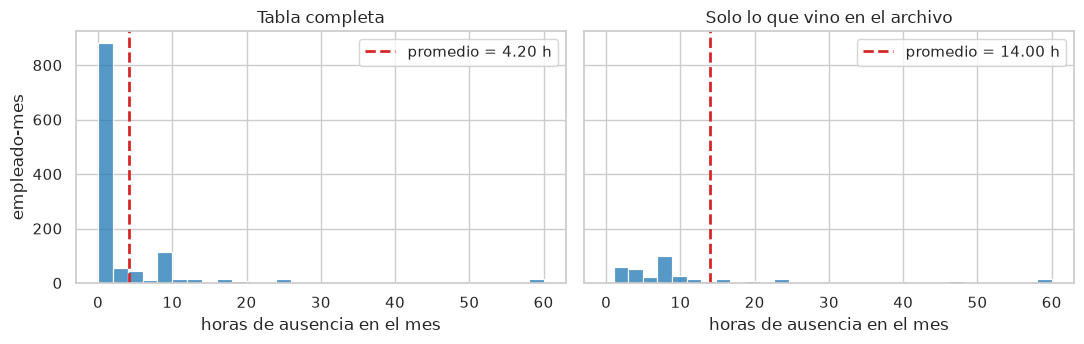

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
paneles = [('Tabla completa', completa['horas_ausencia']),
           ('Solo lo que vino en el archivo', observados['horas_ausencia'])]

for eje, (titulo, datos) in zip(ejes, paneles):
    sns.histplot(datos.clip(upper=60), bins=30, ax=eje, color='tab:blue')
    eje.axvline(datos.mean(), color='tab:red', linestyle='--', linewidth=2,
                label=f'promedio = {datos.mean():.2f} h')
    eje.set_title(titulo)
    eje.set_xlabel('horas de ausencia en el mes')
    eje.legend()

ejes[0].set_ylabel('empleado-mes')
plt.tight_layout()
plt.show()

A la izquierda, la barra de la izquierda del todo son los 855 meses sin ausencias. Son la mayoría, y
tiran el promedio hacia abajo. A la derecha esos meses simplemente no existen, así que el promedio
se calcula solo sobre los meses en que alguien faltó.

### Un detalle que vale la pena: el promedio no es el único piso

In [13]:
mediana = y.median()

print(f'Predecir siempre el PROMEDIO ({y.mean():.2f} h) -> se equivoca en {(y - y.mean()).abs().mean():.1f} h')
print(f'Predecir siempre la MEDIANA  ({mediana:.2f} h) -> se equivoca en {(y - mediana).abs().mean():.1f} h')

Predecir siempre el PROMEDIO (4.20 h) -> se equivoca en 6.2 h
Predecir siempre la MEDIANA  (0.00 h) -> se equivoca en 4.2 h


La mediana es **cero** —la mayoría de los meses no falta nadie— y aun así se equivoca menos que el
promedio. El piso más tonto le gana al que parecía razonable.

No es una curiosidad estadística: es la consecuencia directa de que el 70 % de las filas valen cero.
Y deja instalado que **elegir el baseline ya es una decisión**, no un trámite.

---

# Parte 4 · Ahora ustedes

Una sola tarea, con lo que acabamos de ver.

El **momento de la predicción** es el cierre de cada mes: ahí se decide cuántos turnos cubrir para el
mes siguiente. La pregunta es qué variables están disponibles en ese instante.

**Tarea:** revisen las columnas del archivo y armen dos listas.

```python
df.columns.tolist()
```

- Las que **sí** pueden usarse como predictoras, porque ya estaban registradas antes del cierre.
- Las que **no**, porque solo se conocen después de que la ausencia ocurrió.

Escriban las dos listas en la celda de abajo, como comentario o como listas de Python.

> **Y la pregunta que importa más que el código:** hay una columna que sería con casi total
> seguridad la más informativa de todas para predecir las horas de ausencia. ¿Cuál es, y por qué hay
> que descartarla igual?

In [14]:
# Escriban acá su respuesta

---

## Para cerrar

Lo que hicimos hoy, en orden:

| | |
|:--|:--|
| Contamos | y descubrimos que una fila no era un empleado |
| Construimos | la fila que la decisión necesitaba, con sus ceros |
| Calculamos | el piso contra el que se comparará cualquier modelo |

Ninguna de las tres cosas necesitó un algoritmo, y las tres cambian el resultado de todo lo que
venga después.

El baseline de **4,20 horas con 6,2 de error** queda como la vara. En las próximas clases, cualquier
modelo que construyamos sobre este problema tiene que bajar ese error para justificar su costo.